In [1]:
import matplotlib.pyplot as plt

from unseen import eva
from unseen import similarity

import utils

/g/data/xv83/dbi599/miniconda3/envs/unseen/lib/python3.13/site-packages/xclim/sdba/__init__.py:22: FutureWarning: The SDBA submodule is in the process of being split from `xclim` in order to facilitate development and effective maintenance of the SDBA utilities. The `xclim.sdba` functionality will change in the future. For more information, please visit https://xsdba.readthedocs.io/en/latest/.
  warnings.warn(


In [2]:
location = 'Katherine'
metric = 'rx1day'

### Observations

In [3]:
da_obs = utils.get_obs_data(metric, location)

/g/data/xv83/dbi599/miniconda3/envs/unseen/lib/python3.13/site-packages/xstatstests/scipy.py:246: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  outputs = func(args, **scipy_kwargs)
/g/data/xv83/dbi599/miniconda3/envs/unseen/lib/python3.13/site-packages/xstatstests/scipy.py:246: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  outputs = func(args, **scipy_kwargs)


In [4]:
df_obs = da_obs.to_dataframe()

In [5]:
ranked_years = df_obs.sort_values(by='pr', ascending=False)
print(ranked_years.head(n=10))

                      lat    lon  event_time          pr
time                                                    
2016-06-30 00:00:00 -15.0  131.5  2015-12-26  121.034966
1957-06-30 00:00:00 -15.0  131.5  1957-03-07  117.113503
1998-06-30 00:00:00 -15.0  131.5  1998-01-27  108.367790
1937-06-30 00:00:00 -15.0  131.5  1937-01-07   79.655670
2000-06-30 00:00:00 -15.0  131.5  2000-03-03   75.046738
1914-06-30 00:00:00 -15.0  131.5  1914-01-04   74.041893
1916-06-30 00:00:00 -15.0  131.5  1915-12-24   73.600754
2005-06-30 00:00:00 -15.0  131.5  2005-01-01   70.866669
2004-06-30 00:00:00 -15.0  131.5  2003-12-23   69.717285
1946-06-30 00:00:00 -15.0  131.5  1946-02-15   69.121651


In [6]:
da_obs_detrended, linear_data_obs = utils.detrend_obs(da_obs)

In [7]:
gev_obs_detrended = eva.fit_gev(da_obs_detrended.values)

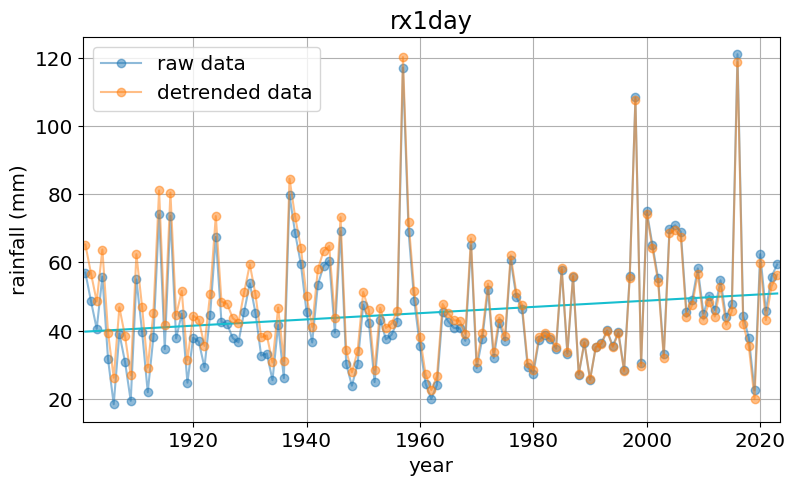

In [8]:
fig, ax = plt.subplots(figsize=[9, 5])
years = da_obs['time'].dt.year.values
plt.plot(years, da_obs.values, marker='o', label='raw data', color='tab:blue', alpha=0.5)
plt.plot(years, linear_data_obs, color='tab:cyan')
plt.plot(years, da_obs_detrended.values, marker='o', label='detrended data', color='tab:orange', alpha=0.5)
plt.xlim(years[0] - 0.5, years[-1] + 0.5)
plt.title('rx1day')
plt.ylabel('rainfall (mm)')
plt.xlabel('year')
plt.legend()
plt.grid()

### Model data

TODO: Write loop to go over all models

In [9]:
model = 'CanESM5'

In [12]:
gev_model_detrended = eva.fit_gev(da_model_detrended_stacked.values)

In [10]:
da_model_stacked = utils.get_model_data(metric, model, location)

In [11]:
da_model_detrended, da_model_detrended_stacked, linear_data_model = utils.detrend_model(da_model_stacked)

In [13]:
da_model_detrended_bc_mean_stacked = utils.mean_correction(da_model_detrended, da_obs_detrended, metric)

In [14]:
gev_model_detrended_bc_mean = eva.fit_gev(da_model_detrended_bc_mean_stacked.values)

In [15]:
da_model_detrended_bc_quantile_stacked = utils.quantile_correction(da_model_detrended_stacked, da_obs_detrended, metric)

In [16]:
gev_model_detrended_bc_quantile = eva.fit_gev(da_model_detrended_bc_quantile_stacked.values)

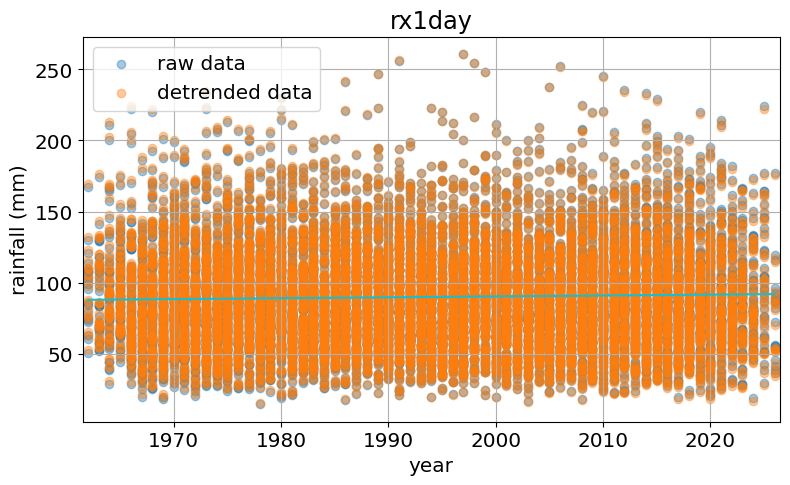

In [17]:
utils.plot_model_data(da_model_stacked, da_model_detrended_stacked, linear_data_model, metric)

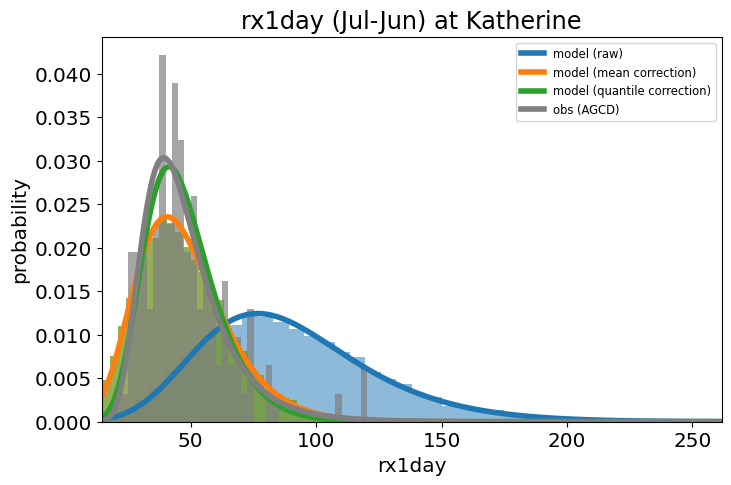

In [18]:
utils.plot_distributions(
    metric,
    location,
    da_obs_detrended,
    gev_obs_detrended,
    da_model_detrended_stacked,
    gev_model_detrended,
    da_model_detrended_bc_mean_stacked,
    gev_model_detrended_bc_mean,
    da_model_detrended_bc_quantile_stacked,
    gev_model_detrended_bc_quantile,
)

In [19]:
similarity_ds = similarity.similarity_tests(da_model_detrended, da_obs_detrended)
print('KS score:', similarity_ds['ks_statistic'].values)
print('KS p-value:', similarity_ds['ks_pval'].values)
print('AD score:', similarity_ds['ad_statistic'].values)
print('AD p-value:', similarity_ds['ad_pval'].values)

KS score: 0.6194718
KS p-value: 1e-45
AD score: 167.3451
AD p-value: 0.001


KS score: 0.048942138
KS p-value: 0.9179833
AD score: -0.7428875
AD p-value: 0.25


INFO:root:mean: Obs = 47.90504455566408, Model 95% CI =84.02774229689562 to 95.73129841220738
INFO:root:standard deviation: Obs = 17.30361181846401, Model 95% CI =30.2336118468867 to 40.178240878158505
INFO:root:skew: Obs = 1.5957395904422786, Model 95% CI =0.2422832119922136 to 1.2156466782333144
INFO:root:kurtosis: Obs = 3.9627037167355947, Model 95% CI =-0.6354347848157678 to 2.756263696122914
INFO:root:GEV shape: Obs = -0.06906796433201988, Model 95% CI =-0.0581367606692503 to 0.20208618520068952
INFO:root:GEV location: Obs = 40.01068449094637, Model 95% CI =68.87546486032713 to 80.80810452386696
INFO:root:GEV scale: Obs = 12.153049415078883, Model 95% CI =25.522763976032902 to 33.21080874292986
INFO:root:mean: Obs = 47.90504455566408, Bias corrected model 95% CI =44.6045964014591 to 49.87893725900308
INFO:root:standard deviation: Obs = 17.30361181846401, Bias corrected model 95% CI =12.713499532720565 to 17.342817489005046
INFO:root:skew: Obs = 1.5957395904422786, Bias corrected m

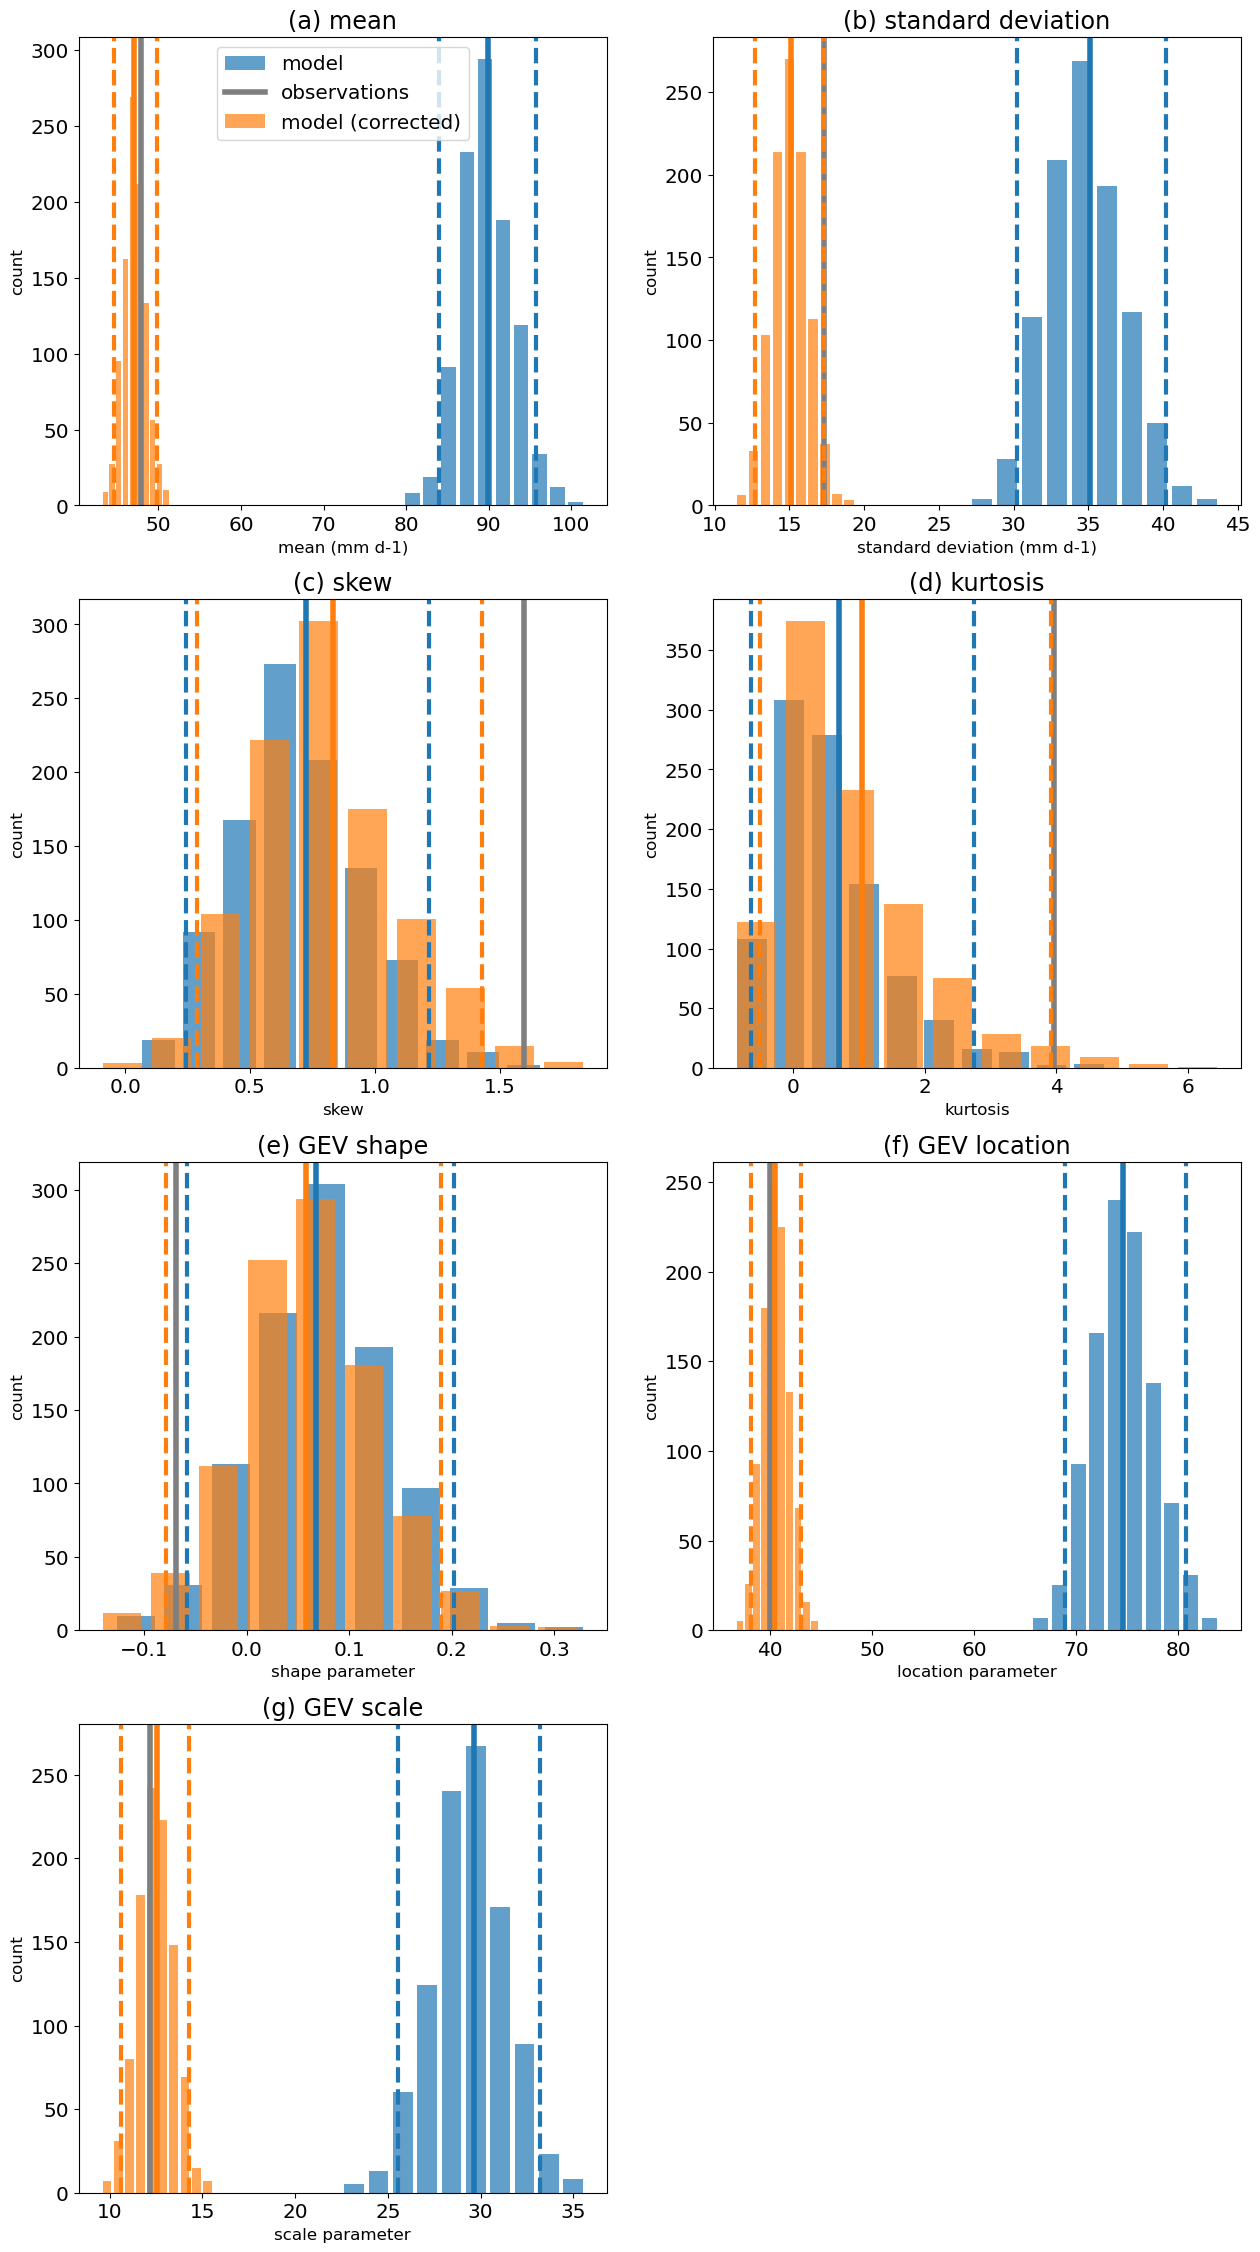

In [20]:
utils.fidelity_tests(da_model_detrended, da_obs_detrended, da_model_detrended_bc_quantile_stacked.unstack())

KS score: 0.08500689
KS p-value: 0.3228596
AD score: 1.1308315
AD p-value: 0.11139941


INFO:root:mean: Obs = 47.90504455566408, Model 95% CI =83.98740902185683 to 96.12046432214844
INFO:root:standard deviation: Obs = 17.30361181846401, Model 95% CI =29.741840670246503 to 40.1017006283488
INFO:root:skew: Obs = 1.5957395904422786, Model 95% CI =0.2404711529962532 to 1.20654261318241
INFO:root:kurtosis: Obs = 3.9627037167355947, Model 95% CI =-0.5954475220238941 to 2.5483505433320617
INFO:root:GEV shape: Obs = -0.06906796433201988, Model 95% CI =-0.05049267496685554 to 0.20447758157733512
INFO:root:GEV location: Obs = 40.01068449094637, Model 95% CI =69.03095966844955 to 80.68304145586978
INFO:root:GEV scale: Obs = 12.153049415078883, Model 95% CI =25.56734004689012 to 33.34537343476235
INFO:root:mean: Obs = 47.90504455566408, Bias corrected model 95% CI =44.020666224838266 to 50.885307384120665
INFO:root:standard deviation: Obs = 17.30361181846401, Bias corrected model 95% CI =15.837007361270633 to 21.051211623649507
INFO:root:skew: Obs = 1.5957395904422786, Bias corrected

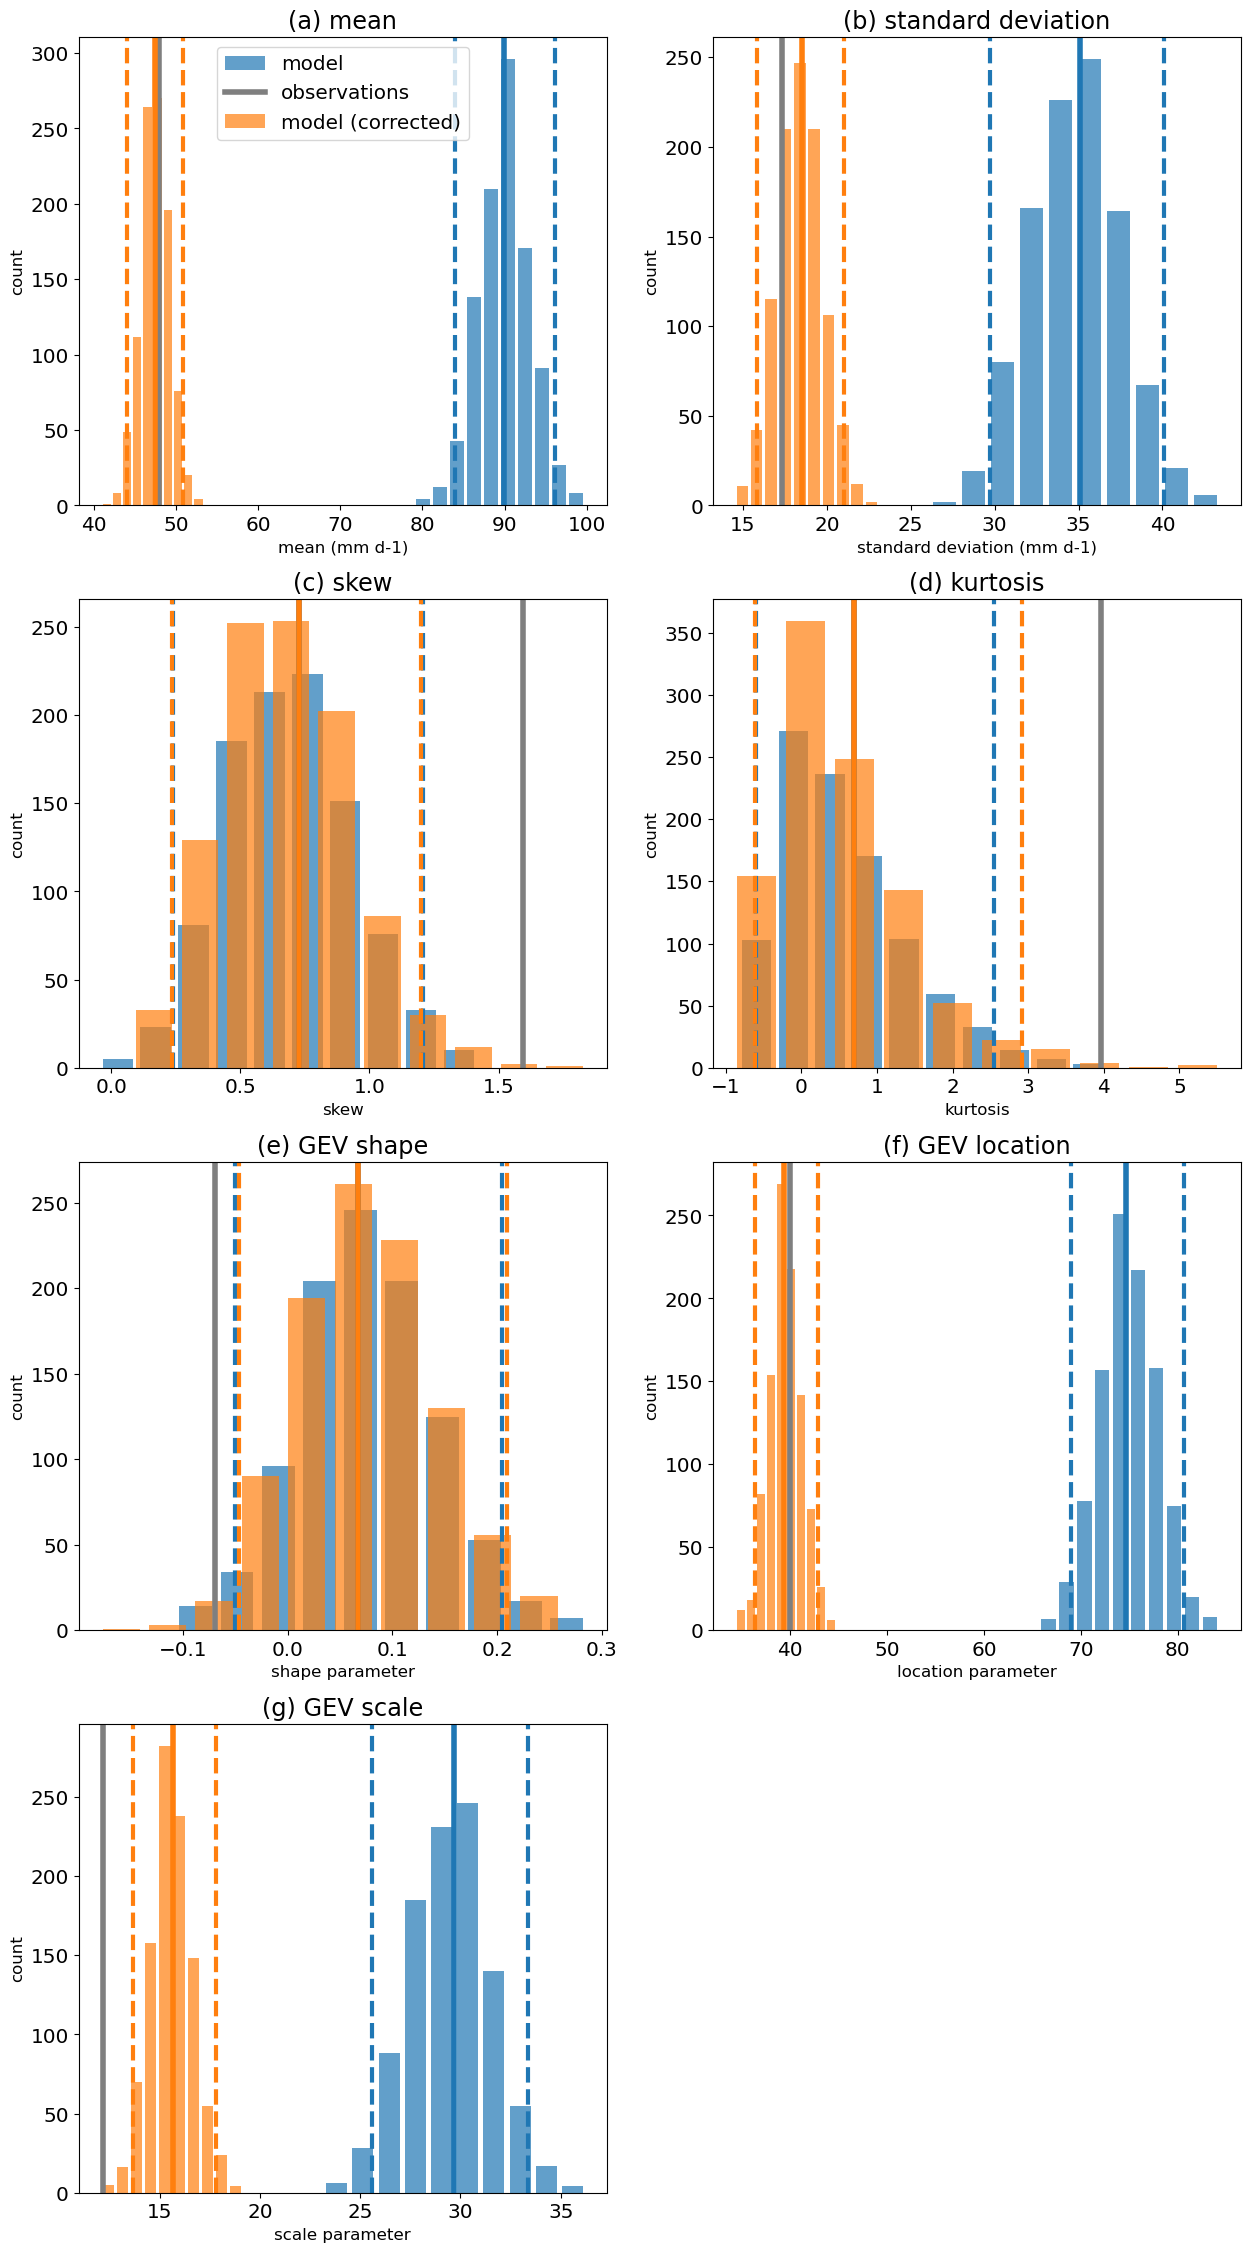

In [21]:
utils.fidelity_tests(da_model_detrended, da_obs_detrended, da_model_detrended_bc_mean_stacked.unstack())